# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">MatrixBrekzie 60°</font>

<font size="6">Test 1: (failed data logging)</font>

In [ ]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_60_5N//log_202405241609.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 554
Average Fx in the averaging interval [1530:2084]: 5.591158822584095
Average Fz in the averaging interval [1530:2084]: 1.0403408303014066
Maximum Fz in the plotting interval [1530:None]: 2.1368367513020834 at timestep 2034
Time step where Fx drops below 1: 2084


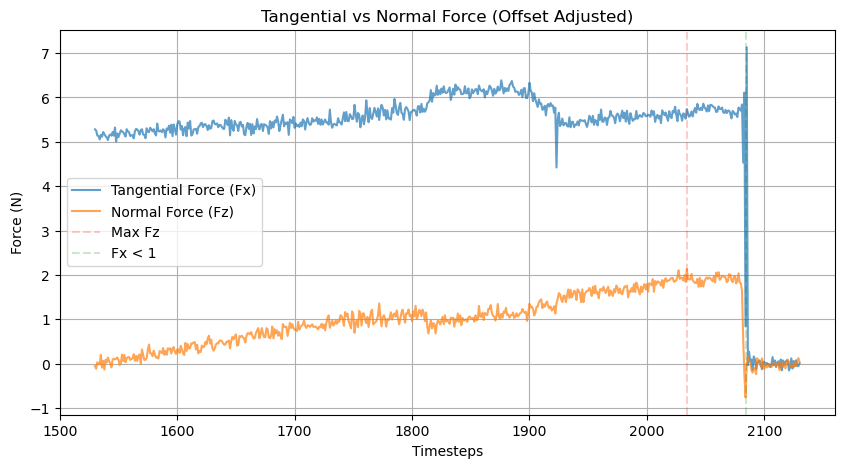

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_60_5N//log_202405241611.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=1530, cut_2=None, avg_end=2084, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 444
Average Fx in the averaging interval [1015:1459]: 5.246578456689646
Average Fz in the averaging interval [1015:1459]: 1.1692319577878658
Maximum Fz in the plotting interval [1015:1480]: 2.245552571614583 at timestep 1430
Time step where Fx drops below 1: 1459


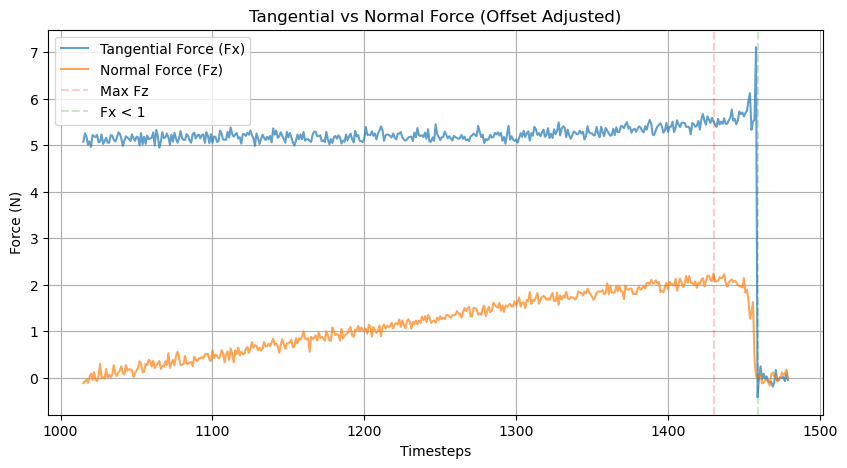

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_60_5N//log_202405241612.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=1015, cut_2=1480, avg_end=1459, offset_position='end', offset_length=15)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 996
Average Fx in the averaging interval [900:1896]: 5.694596071128386
Average Fz in the averaging interval [900:1896]: 2.275891971205133
Maximum Fz in the plotting interval [900:None]: 4.239473470052084 at timestep 1880
Time step where Fx drops below 1: 1896


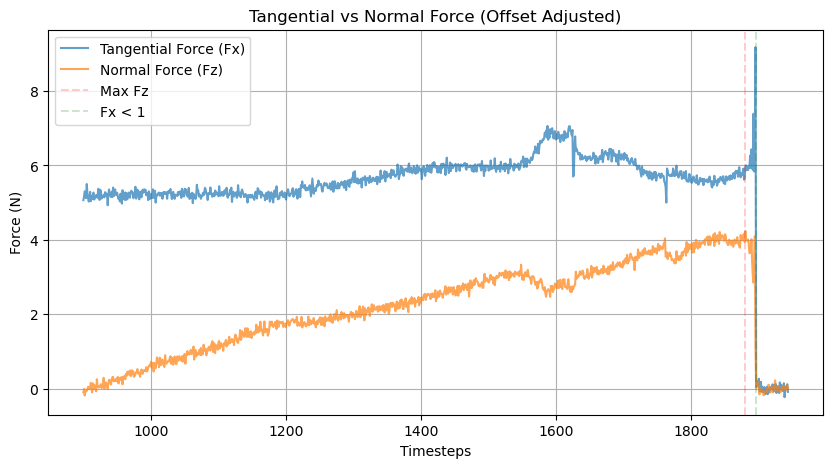

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_60_5N//log_202405241613.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=900, cut_2=None, avg_end=1896, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 1370
Average Fx in the averaging interval [580:1950]: 5.459036797386597
Average Fz in the averaging interval [580:1950]: 1.8822857859070865
Maximum Fz in the plotting interval [580:None]: 4.317753092447917 at timestep 1916
Time step where Fx drops below 1: 1950


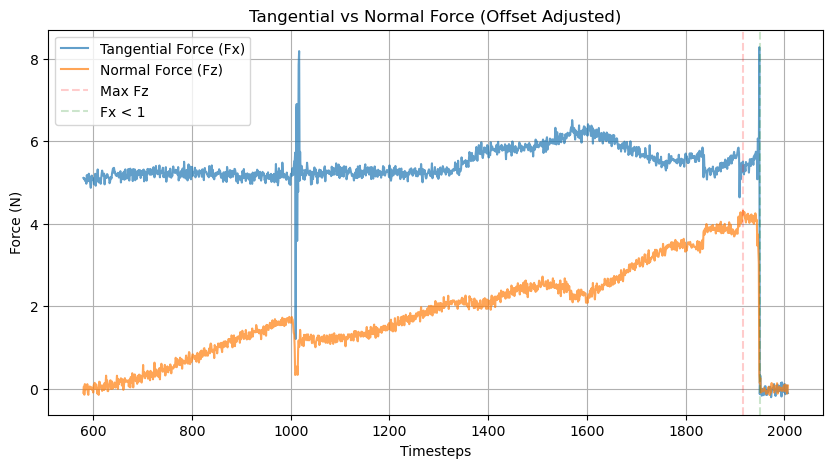

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_60_5N//log_202405241615.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=580, cut_2=None, avg_end=1950, offset_position='end', offset_length=15, fx_threshold=1)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 618
Average Fx in the averaging interval [960:1578]: 5.597277860116804
Average Fz in the averaging interval [960:1578]: 1.246218348629652
Maximum Fz in the plotting interval [960:None]: 2.5086385091145833 at timestep 1559
Time step where Fx drops below 1: 1578


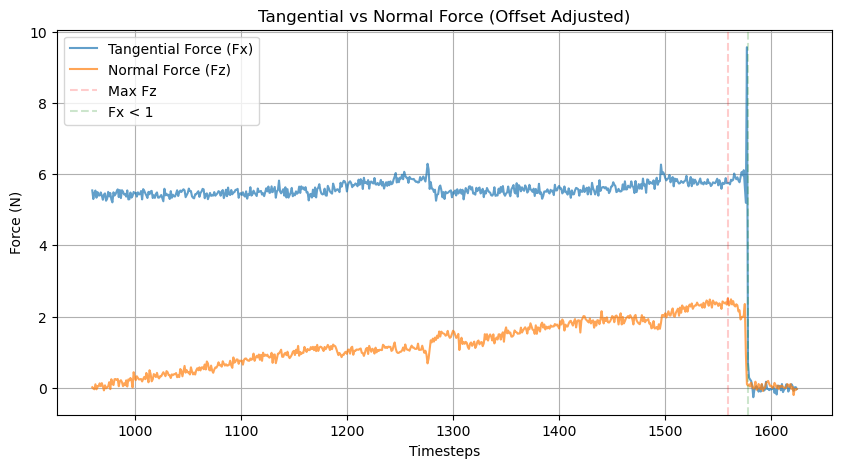

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_60_5N//log_202405241616.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=960, cut_2=None, avg_end=1578, offset_position='end', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 1280
Average Fx in the averaging interval [350:1630]: 4.7776126594593125
Average Fz in the averaging interval [350:1630]: 1.8252000490824383
Maximum Fz in the plotting interval [350:None]: 4.353751627604167 at timestep 1587
Time step where Fx drops below 1: 1630


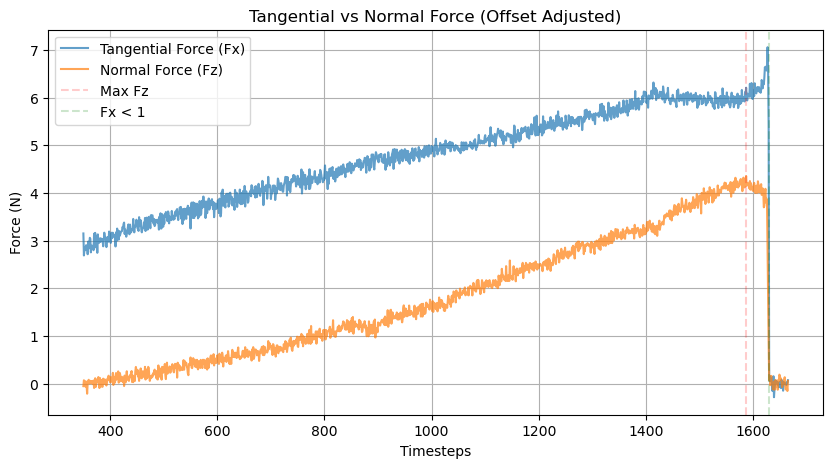

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_60_5N//log_202405241618.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=350, cut_2=None, avg_end=1630, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 968
Average Fx in the averaging interval [640:1608]: 5.399551382997476
Average Fz in the averaging interval [640:1608]: 1.8961877197601906
Maximum Fz in the plotting interval [640:None]: 3.7501383463541664 at timestep 1474
Time step where Fx drops below 1: 1608


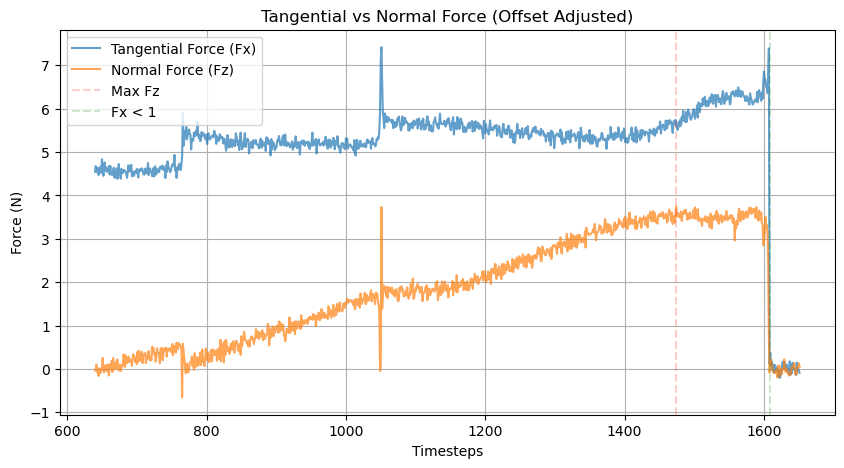

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_60_5N//log_202405241619.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=640, cut_2=None, avg_end=1608, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 1041
Average Fx in the averaging interval [836:1877]: 5.8229520168359405
Average Fz in the averaging interval [836:1877]: 1.988946316267411
Maximum Fz in the plotting interval [836:None]: 3.662060546875 at timestep 1863
Time step where Fx drops below 1: 1877


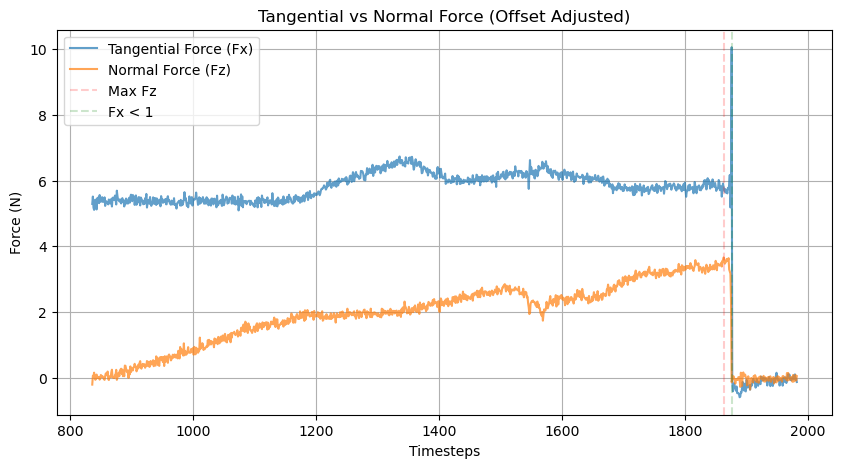

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_60_5N//log_202405241620.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=836, cut_2=None, avg_end=1877, offset_position='end', offset_length=15)

<font size="6">Test 10a: (worked)</font>

Length from cut_1 to avg_end: 104
Average Fx in the averaging interval [1053:1157]: 5.563226812313765
Average Fz in the averaging interval [1053:1157]: 0.35606380364833734
Maximum Fz in the plotting interval [1053:1200]: 0.7579386393229167 at timestep 1130
Time step where Fx drops below 1: 1158


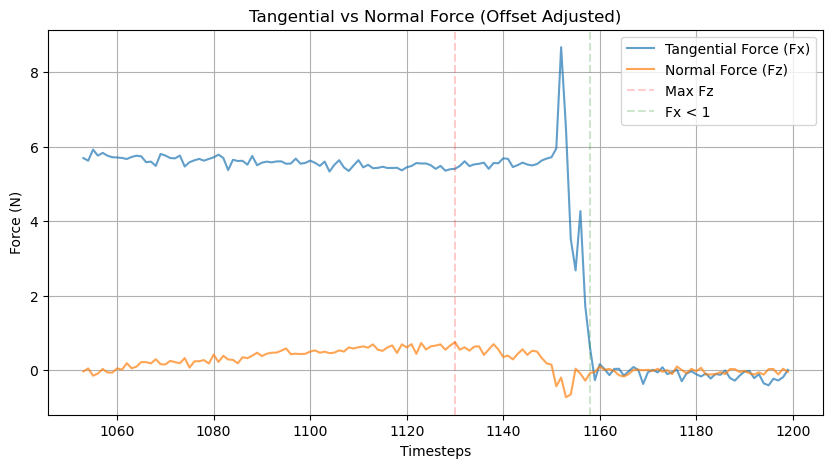

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_60_5N//log_202405241624.csv"
df = pd.read_csv(data)
test_10a, end_10a = plot_forces(df, cut_1=1053, cut_2=1200, avg_end=1157, offset_position='beginning', offset_length=15)

<font size="6">Test 10b: (worked)</font>

Length from cut_1 to avg_end: 525
Average Fx in the averaging interval [1251:1776]: 4.094946938469296
Average Fz in the averaging interval [1251:1776]: 1.5833120582217262
Maximum Fz in the plotting interval [1251:None]: 2.5079508463541664 at timestep 1706
Time step where Fx drops below 1: 1776


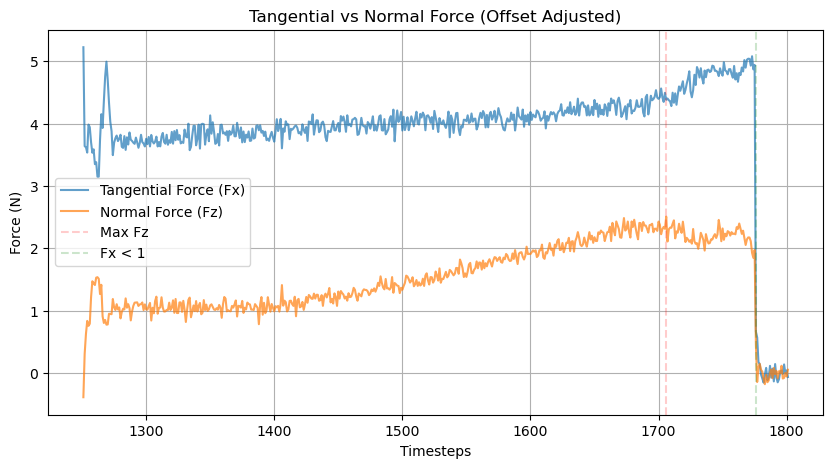

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//MatrixBrekzie_60_5N//log_202405241624.csv"
df = pd.read_csv(data)
test_10b, end_10b = plot_forces(df, cut_1=1251, cut_2=None, avg_end=1776, offset_position='end', offset_length=15)

In [13]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [17]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//60//MatrixBrekzie_60_stats.csv", index=False)

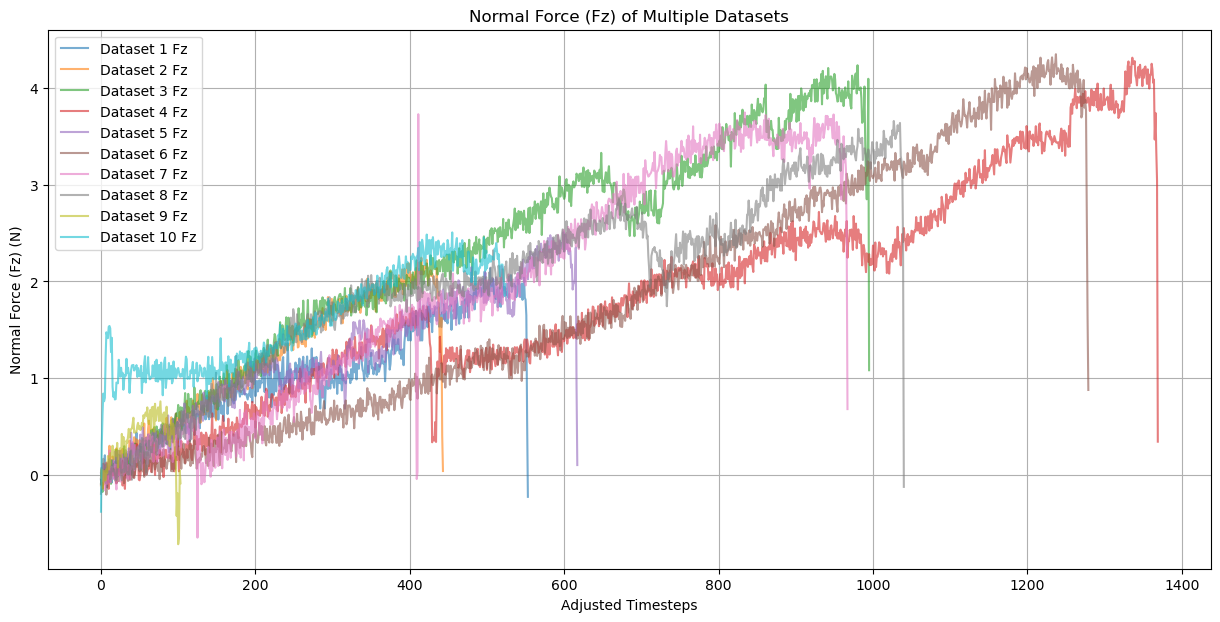

Average of maximum Fz forces: 3.0480094401041664
Standard deviation of maximum Fz forces: 1.1361348138904188
Average of average Fz forces: 1.5263678840811246
Standard deviation of average Fz forces: 0.5425510573539839
Average of average Fx forces: 5.324693781798132
Standard deviation of average Fx forces: 0.4928104544552496


In [18]:
tests = [test_2, test_3, test_4, test_5, test_6, test_7, test_8, test_9, test_10a, test_10b]
ends = [end_2, end_3, end_4, end_5, end_6, end_7, end_8, end_9, end_10a, end_10b]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [19]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//60//MatrixBrekzie_60"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)